# Environment

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import DistanceBand
from scipy.sparse import identity
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import statsmodels.api as sm
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
from scipy.spatial import cKDTree

In [3]:
import sys
from pathlib import Path
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from data_exploration_functions import *

In [6]:
def generate_spillovers(coords, gdf, mean_tau_treated,
                        distance_ring_number,
                        spacing,
                        scalars,
                        noise_scale=0.1,
                        seed=None):


    if seed is not None:
        np.random.seed(seed)

    if len(scalars) != distance_ring_number:
        raise ValueError("Długość 'scalars' musi być równa distance_ring_number")

    treated_coords = coords[gdf["T"] == 1]
    tree = cKDTree(treated_coords)

    dist, _ = tree.query(coords, k=1)

    n = len(coords)
    spill = np.zeros(n)

    for i in range(distance_ring_number):
        lower = i * spacing
        upper = (i + 1) * spacing

        ring_mask = (dist > lower) & (dist <= upper)

        spill[ring_mask] = np.random.normal(
            loc=scalars[i] * mean_tau_treated,
            scale=noise_scale,
            size=ring_mask.sum()
        )

    return spill

# Creating geo points

# Creating causal structure

In [31]:
def return_spatial_geo_df(n_x: int,  
    n_y: int,   
    spacing: int, 
    treated_scope_x_start: int,
    treated_scope_x_end: int,
    treated_scope_y_start: int,
    treated_scope_y_end: int,
    ATT_target: float,
    y_spatial_autocorelation_scope_x_start: int,
    y_spatial_autocorelation_scope_x_end: int,
    y_spatial_autocorelation_scope_y_start: int,
    y_spatial_autocorelation_scope_y_end: int,
    rho: float,
    spatial_confounder_scope_x_start: int,
    spatial_confounder_scope_x_end: int,
    spatial_confounder_scope_y_start: int,
    spatial_confounder_scope_y_end: int,
    lambda_cs: float,
    distance_ring_number: int,
    distance_ring_ate_scalars: list,
    nonspatial_confounders_contribution_to_Y: float,
    spatial_confounder_contribution_to_Y: float,
    epsilon_distribution_mean: float,
    epsilon_distribution_standard_error: float):


    spatial_confounder_scope_x_start_spacing = spatial_confounder_scope_x_start * spacing
    spatial_confounder_scope_x_end_spacing = spatial_confounder_scope_x_end * spacing
    spatial_confounder_scope_y_start_spacing = spatial_confounder_scope_y_start * spacing
    spatial_confounder_scope_y_end_spacing = spatial_confounder_scope_y_end * spacing

    y_spatial_autocorelation_scope_x_start_spacing = y_spatial_autocorelation_scope_x_start * spacing
    y_spatial_autocorelation_scope_x_end_spacing = y_spatial_autocorelation_scope_x_end * spacing
    y_spatial_autocorelation_scope_y_start_spacing = y_spatial_autocorelation_scope_y_start * spacing
    y_spatial_autocorelation_scope_y_end_spacing = y_spatial_autocorelation_scope_y_end * spacing

    y_start, y_end, y_step = (treated_scope_x_start)*spacing, (treated_scope_x_end)*spacing, spacing
    x_start, x_end, x_step = (treated_scope_y_start)*spacing, (treated_scope_y_end)*spacing, spacing

    y_vals = np.arange(y_start, y_end + y_step, y_step)
    x_vals = np.arange(x_start, x_end + x_step, x_step)



    origin_x, origin_y = 0, 0

    points = []

    for i in range(n_x):
        for j in range(n_y):
            x = origin_x + i * spacing
            y = origin_y + j * spacing
            points.append(Point(x, y))

    gdf = gpd.GeoDataFrame(geometry=points)

    gdf.set_crs(epsg=3857, inplace=True)
    gdf2 = gdf.reset_index() 
    gdf2 = gdf2.rename(columns = {'index': 'unit_id'})
    gdf2['unit_id'] = 1000 + gdf2['unit_id']
    gdf2["x"] = gdf2.geometry.x.astype(int)
    gdf2["y"] = gdf2.geometry.y.astype(int)
    gdf = gdf2.copy()
    n = len(gdf)

    coords = np.array(list(zip(gdf["x"], gdf["y"])))

    # -------------------------
    # 1. DITANCE MATRIX (100m)
    # -------------------------
    W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
    W.transform = "R"  # row-standardization

    W_sparse = W.sparse

    # -------------------------
    # 2. TREATMENT (PREDEFINED)
    # -------------------------
    treated_mask = (
        gdf['y'].isin(y_vals) &
        gdf['x'].isin(x_vals)
    )

    gdf["T"] = treated_mask.astype(int)

    # -------------------------
    # 3. NONSPATIAL CONFOUNDERS 
    # -------------------------
    C1 = np.random.normal(0,1,n)
    C2 = np.random.normal(0,1,n)
    C3 = np.random.normal(0,1,n)


    fC = (
        0.6*C1 + 0.5*C2 + 0.4*C3 +
        0.1*C1**2 - 0.1*C2*C3
    )

    # -------------------------
    # 4. SPATIAL CONFOUNDER 
    # -------------------------
    eta = np.random.normal(0,1,n)


    mask_cs = (
        (gdf["y"].between(spatial_confounder_scope_y_start_spacing,spatial_confounder_scope_y_end_spacing)) &
        (gdf["x"].between(spatial_confounder_scope_x_start_spacing,spatial_confounder_scope_x_end_spacing))
    )  

    Cs = eta.copy()
    for _ in range(5):
        Cs = lambda_cs * W_sparse.dot(Cs) + eta

    Cs[~mask_cs] = eta[~mask_cs]

    # -------------------------
    # 5. "PROPENSITY" 
    # -------------------------
    T_star = 1.2*fC + 0.8*Cs + np.random.normal(0,0.5,n)

    gdf["propensity"] = T_star

    # -------------------------
    # 6. ITE (only for treated)
    # -------------------------
    tau = np.zeros(n)

    # tau[gdf["T"]==1] = np.random.normal(
    #     loc = 1 + 0.3*C1[gdf["T"]==1] + 0.2*C2[gdf["T"]==1],
    #     scale = 0.2
    # )
    tau[gdf["T"]==1] = np.random.normal(
        loc = 1 + 0.3*C1[gdf["T"]==1] + 0.2*C2[gdf["T"]==1],
        scale = 0.2
    )

    mean_tau_treated = tau[gdf["T"]==1].mean()

    tau[gdf["T"]==1] += (ATT_target - mean_tau_treated)

    mean_tau_treated = tau[gdf["T"]==1].mean()


    # -------------------------
    # 7. SPILLOVERS (rings)
    # -------------------------


    spill = generate_spillovers(
        coords=coords,
        gdf=gdf,
        mean_tau_treated=mean_tau_treated,
        distance_ring_number=distance_ring_number,
        spacing=spacing,
        scalars=distance_ring_ate_scalars,
        seed=42
    )


    # -------------------------
    # 8. BASE Y (without spatial autocorrelation)
    # -------------------------
    epsilon = np.random.normal(epsilon_distribution_mean, epsilon_distribution_standard_error , n)

    Y_base = (
        nonspatial_confounders_contribution_to_Y*fC +
        spatial_confounder_contribution_to_Y*Cs +
        tau * gdf["T"] +
        spill +
        epsilon
    )

    # -------------------------
    # 9. SPATIAL AUTOCORRELATION OF Y (LOCAL)
    # -------------------------

    mask_y = (
        (gdf["y"].between(y_spatial_autocorelation_scope_y_start_spacing,y_spatial_autocorelation_scope_y_end_spacing)) &
        (gdf["x"].between(y_spatial_autocorelation_scope_x_start_spacing,y_spatial_autocorelation_scope_x_end_spacing))
    )

    W2 = W_sparse.copy().tolil()

    for i in range(n):
        if not mask_y.iloc[i]:
            W2[i,:] = 0

    W2 = W2.tocsr()

    I = identity(n)

    Y = spsolve(I - rho * W2, Y_base)


    gdf["C1"] = C1
    gdf["C2"] = C2
    gdf["C3"] = C3
    gdf["Cs"] = Cs

    gdf["tau"] = tau
    gdf["spill"] = spill
    gdf["Y"] = Y
    gdf["Y_ns"] = Y_base 
    return gdf

In [16]:
gdf[gdf['T'] != 0]['tau'].mean()

np.float64(1.0156626238262754)

## Checking data

In [32]:
gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 25,    
    spacing = 100, 
    treated_scope_x_start = 7,
    treated_scope_x_end = 14,
    treated_scope_y_start = 11,
    treated_scope_y_end = 24,
    ATT_target = 1.5,
    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 17,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 13,
    rho = 0.15,
    spatial_confounder_scope_x_start = 15,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 14,
    spatial_confounder_scope_y_end = 20,
    lambda_cs = 0.2,
    distance_ring_number = 2,
    distance_ring_ate_scalars=[0.4, 0.15],
    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

In [33]:
gdf_output[gdf_output['T']==1]['tau'].mean()

np.float64(1.5)

In [30]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,C1,C2,C3,Cs,tau,spill,Y,Y_ns
232,1232,POINT (900 700),900,700,0,0.063347,0.064474,-0.005596,1.103877,-0.762519,0.0,0.152148,-0.040459,-0.079348
233,1233,POINT (900 800),900,800,0,0.461605,-1.975467,0.668742,0.475168,1.036303,0.0,0.228016,0.367854,0.433218
234,1234,POINT (900 900),900,900,0,-1.962235,-0.939335,-1.091701,-0.002404,-0.595535,0.0,0.253936,-0.910924,-0.928757
235,1235,POINT (900 1000),900,1000,0,0.185593,-0.144088,-0.387100,-0.589272,0.900533,0.0,0.405712,0.737676,0.682972
236,1236,POINT (900 1100),900,1100,0,0.886207,-1.209695,0.695538,-1.092164,1.699436,0.0,0.334362,1.148301,1.081178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,1660,POINT (2600 1000),2600,1000,0,0.479067,-0.654076,-0.465806,1.252843,-0.235917,0.0,0.332875,-0.025513,-0.025513
661,1661,POINT (2600 1100),2600,1100,0,-2.233167,-1.830633,-0.150838,-0.448225,-0.406885,0.0,0.247024,-0.826795,-0.826795
662,1662,POINT (2600 1200),2600,1200,0,-0.509064,0.511203,-0.073948,-0.692250,-0.534757,0.0,0.351327,-0.174021,-0.174021
663,1663,POINT (2600 1300),2600,1300,0,-0.392485,1.373659,-0.451659,-1.968923,0.294971,0.0,0.309708,0.978226,0.978226


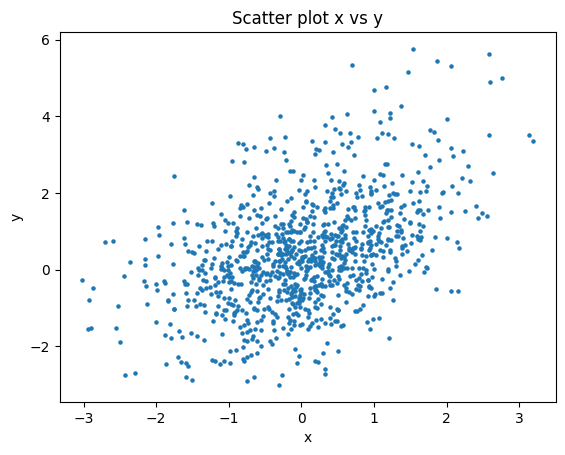

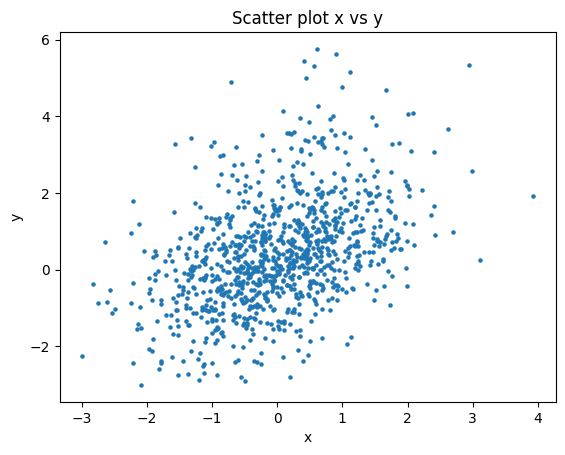

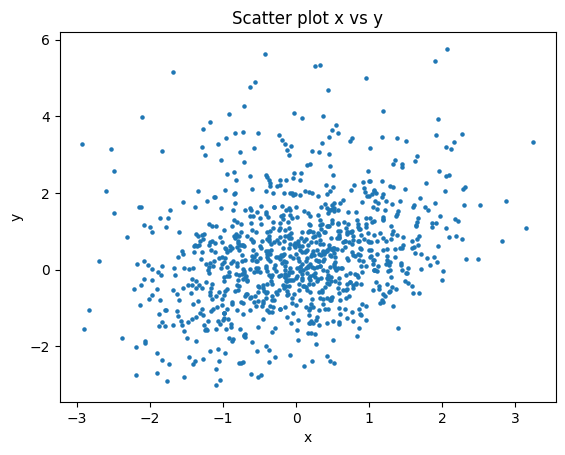

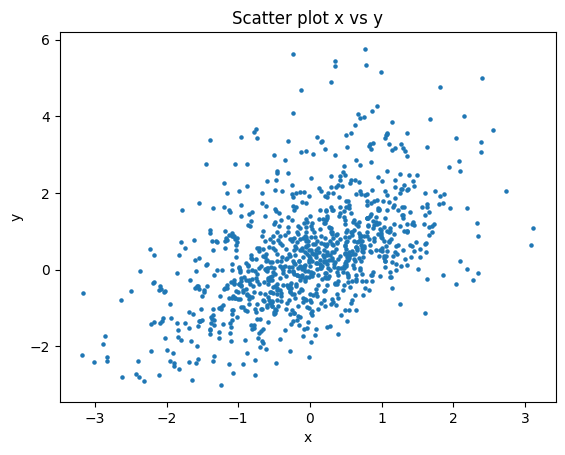

In [25]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Scatter plot x vs y")
    plt.show()

In [34]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

In [35]:
X_logit = sm.add_constant(X)

logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.348901
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                0.005064
Time:                        16:32:10   Log-Likelihood:                -348.90
converged:                       True   LL-Null:                       -350.68
Covariance Type:            nonrobust   LLR p-value:                    0.1693
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0915      0.102    -20.468      0.000      -2.292      -1.891
x1             0.1505      0.

In [36]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:        1000
Mean dependent var  :      0.3512                Number of Variables   :           8
S.D. dependent var  :      1.3236                Degrees of Freedom    :         992
Pseudo R-squared    :      0.5766
Spatial Pseudo R-squared:  0.5761
Log likelihood      :  -1269.3060
Sigma-square ML     :      0.7411                Akaike info criterion :    2554.612
S.E of regression   :      0.8609                Schwarz criterion     :    2593.874

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

In [37]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     420.7
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.74e-176
Time:                        16:32:42   Log-Likelihood:                -1276.4
No. Observations:                1000   AIC:                             2561.
Df Residuals:                     996   BIC:                             2580.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1371      0.029      4.702      0.0

In [38]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate

In [39]:
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()

In [40]:
gdf_rf_compare['tau_cf'] = tau_hat

In [41]:
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
282,1282,POINT (1100 700),1,2.066491,2.436005
283,1283,POINT (1100 800),1,1.486865,1.541992
284,1284,POINT (1100 900),1,1.175956,1.344254
285,1285,POINT (1100 1000),1,1.628610,1.870254
286,1286,POINT (1100 1100),1,0.941156,1.568398
...,...,...,...,...,...
610,1610,POINT (2400 1000),1,1.955423,1.752391
611,1611,POINT (2400 1100),1,1.861401,2.188732
612,1612,POINT (2400 1200),1,1.387580,1.279557
613,1613,POINT (2400 1300),1,2.029224,1.834880


In [42]:
ate

np.float64(1.6013051756708705)

In [44]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.6039228348885737)

In [61]:
ci_low_ate, ci_high_ate

(np.float64(0.8369656992847754), np.float64(0.9117297050478765))